# LIME y SHAP en datos tabulares

Este notebook está diseñado para enseñar, paso a paso, cómo interpretar modelos de **regresión** y **clasificación** con datos tabulares usando:

- **LIME**: explicación local, alrededor de una fila
- **SHAP**: explicación por contribuciones

Usaremos variables con nombres fáciles de explicar en clase:

- `horas_estudio`
- `ausencias`
- `tareas_entregadas`
- `participacion`
- `promedio_previo`
- `uso_plataforma`

El notebook tiene dos partes:

1. **Regresión**: predecir una nota final
2. **Clasificación**: predecir si aprueba o no aprueba

In [ ]:
# ==========================================================
# BLOQUE 0. INSTALAR LIBRERÍAS
# ==========================================================
!pip -q install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ==========================================================
# BLOQUE 1. IMPORTAR LIBRERÍAS
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

from lime.lime_tabular import LimeTabularExplainer
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# ==========================================================
# BLOQUE 2. FUNCIÓN AUXILIAR PARA GRÁFICOS MÁS CLAROS
# ==========================================================
# Esta función no cambia colores manualmente.
# Solo mejora tamaño, títulos y rejilla para que se vea mejor en clase.

def configurar_grafico(titulo, xlabel="", ylabel=""):
    plt.figure(figsize=(10, 5))
    plt.title(titulo, fontsize=14)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, alpha=0.3)

## Parte 1. Regresión

Aquí queremos predecir una **nota final** (un número continuo).

La idea pedagógica es esta:

- cada fila representa un estudiante
- tenemos variables académicas y de comportamiento
- el modelo intenta predecir `nota_final`

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 3. CREAR UN DATASET DIDÁCTICO DE REGRESIÓN
# ==========================================================
n = 5000

horas_estudio = np.random.normal(loc=5, scale=2, size=n).clip(0, 12)
ausencias = np.random.poisson(lam=2, size=n).clip(0, 10)
tareas_entregadas = np.random.randint(0, 11, size=n)
participacion = np.random.randint(1, 6, size=n)
promedio_previo = np.random.normal(loc=3.5, scale=0.7, size=n).clip(1, 5)
uso_plataforma = np.random.randint(0, 8, size=n)

ruido = np.random.normal(0, 2, size=n)

nota_final = (
    45
    + 3.2 * horas_estudio
    - 2.8 * ausencias
    + 1.5 * tareas_entregadas
    + 2.2 * participacion
    + 4.5 * promedio_previo
    + 1.0 * uso_plataforma
    + ruido
)

nota_final = np.clip(nota_final, 0, 100)

df_reg = pd.DataFrame({
    "horas_estudio": horas_estudio,
    "ausencias": ausencias,
    "tareas_entregadas": tareas_entregadas,
    "participacion": participacion,
    "promedio_previo": promedio_previo,
    "uso_plataforma": uso_plataforma,
    "nota_final": nota_final
})

print("Primeras filas del dataset de regresión:")
display(df_reg.head())

print("\nResumen estadístico:")
display(df_reg.describe().round(2))

Primeras filas del dataset de regresión:


,horas_estudio,ausencias,tareas_entregadas,participacion,promedio_previo,uso_plataforma,nota_final
0,5.993428,1,0,1,4.199563,2,84.613912
1,4.723471,1,8,1,3.182569,4,91.129031
2,6.295377,2,3,4,3.253959,1,86.016617
3,8.046060,2,8,2,3.447306,4,98.547058
4,4.531693,3,8,4,3.253958,3,91.158307



Resumen estadístico:


,horas_estudio,ausencias,tareas_entregadas,participacion,promedio_previo,uso_plataforma,nota_final
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,5.02,2.02,5.06,3.03,3.50,3.53,88.21
std,1.98,1.42,3.15,1.41,0.69,2.29,9.09
min,0.00,0.00,0.00,1.00,1.00,0.00,51.29
25%,3.68,1.00,2.00,2.00,3.03,2.00,81.99
50%,5.03,2.00,5.00,3.00,3.49,4.00,89.06
75%,6.33,3.00,8.00,4.00,3.97,6.00,96.00
max,12.00,8.00,10.00,5.00,5.00,7.00,100.00


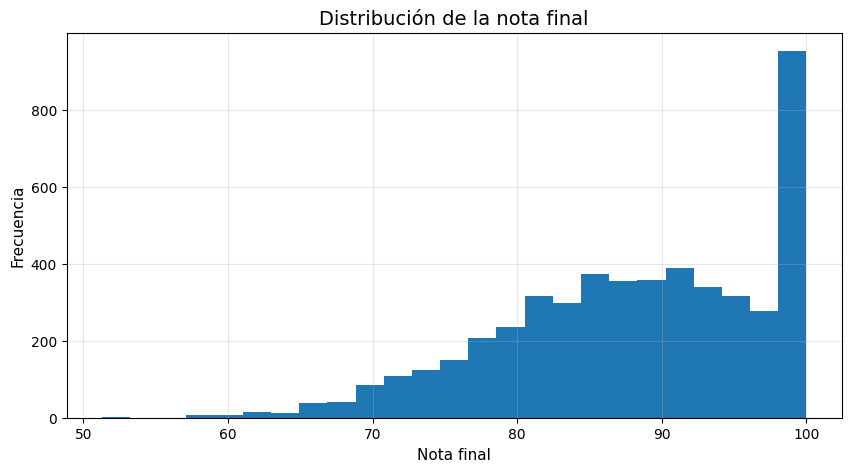

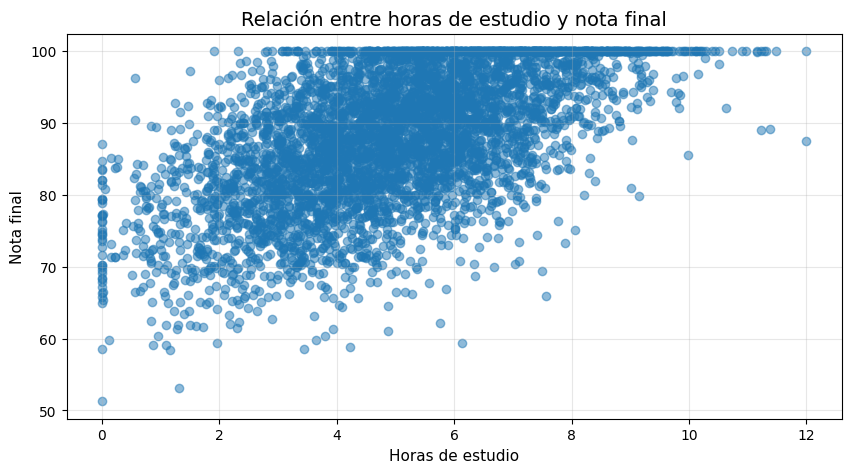

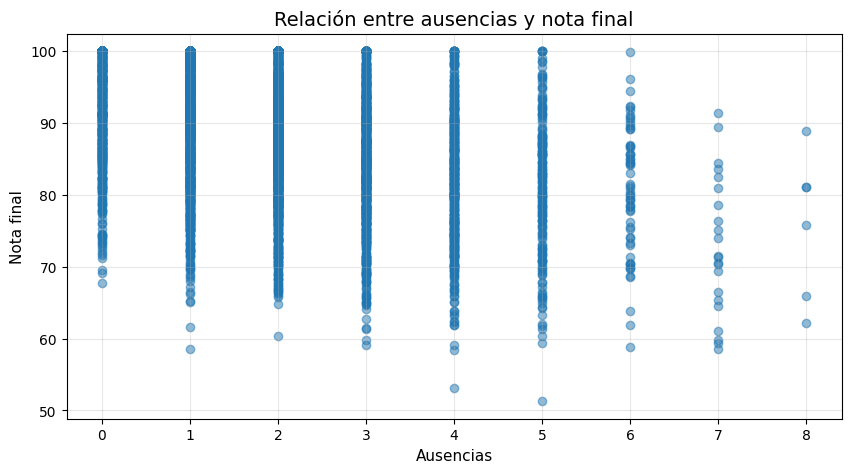

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 4. GRÁFICOS INICIALES PARA DISCUSIÓN EN CLASE
# ==========================================================
# Gráfico 1: distribución de la nota final
configurar_grafico("Distribución de la nota final", "Nota final", "Frecuencia")
plt.hist(df_reg["nota_final"], bins=25)
plt.show()

# Gráfico 2: relación entre horas de estudio y nota final
configurar_grafico("Relación entre horas de estudio y nota final", "Horas de estudio", "Nota final")
plt.scatter(df_reg["horas_estudio"], df_reg["nota_final"], alpha=0.5)
plt.show()

# Gráfico 3: relación entre ausencias y nota final
configurar_grafico("Relación entre ausencias y nota final", "Ausencias", "Nota final")
plt.scatter(df_reg["ausencias"], df_reg["nota_final"], alpha=0.5)
plt.show()

### Preguntas de observación antes del modelo

1. ¿Parece que más horas de estudio se asocian con mejor nota?
2. ¿Parece que más ausencias se asocian con peor nota?
3. ¿La relación parece perfectamente lineal o solo aproximada?

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 5. SEPARAR X Y y
# ==========================================================
X_reg = df_reg.drop(columns=["nota_final"])
y_reg = df_reg["nota_final"]

feature_names_reg = list(X_reg.columns)

print("Variables predictoras:")
print(feature_names_reg)

Variables predictoras:
['horas_estudio', 'ausencias', 'tareas_entregadas', 'participacion', 'promedio_previo', 'uso_plataforma']


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 6. DIVIDIR EN ENTRENAMIENTO Y PRUEBA
# ==========================================================
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Tamaño de X_train_reg:", X_train_reg.shape)
print("Tamaño de X_test_reg :", X_test_reg.shape)

Tamaño de X_train_reg: (4000, 6)
Tamaño de X_test_reg : (1000, 6)


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 7. ENTRENAR EL MODELO DE REGRESIÓN
# ==========================================================
model_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_reg.fit(X_train_reg, y_train_reg)

print("Modelo de regresión entrenado correctamente.")

Modelo de regresión entrenado correctamente.


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 8. EVALUAR EL MODELO
# ==========================================================
y_pred_reg = model_reg.predict(X_test_reg)

mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("=== MÉTRICAS DE REGRESIÓN ===")
print(f"MAE = {mae_reg:.4f}")
print(f"R2  = {r2_reg:.4f}")

=== MÉTRICAS DE REGRESIÓN ===
MAE = 2.5135
R2  = 0.8692


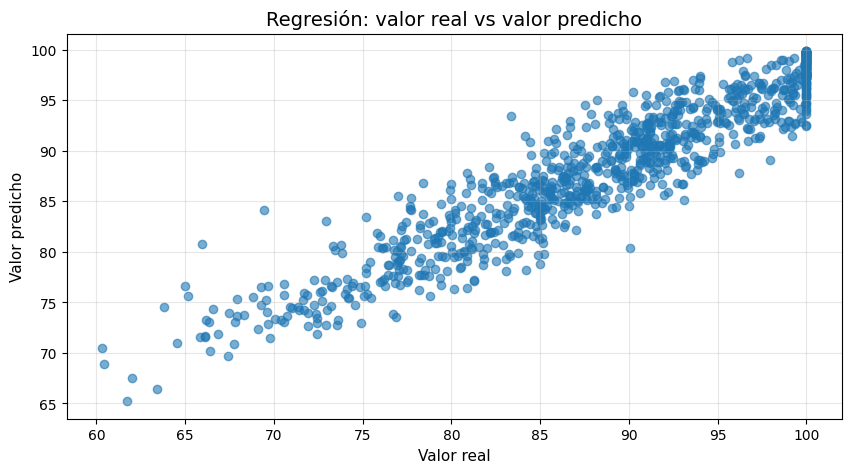

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 9. GRÁFICO DE PREDICHO VS REAL
# ==========================================================
configurar_grafico("Regresión: valor real vs valor predicho", "Valor real", "Valor predicho")
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.show()

### Interpretación de este gráfico

- Si los puntos caen cerca de una diagonal imaginaria, el modelo está prediciendo bien.
- Si están muy dispersos, el modelo se equivoca más.

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 10. ELEGIR UNA FILA PARA EXPLICAR
# ==========================================================
idx_reg = 0
x_instance_reg = X_test_reg.iloc[idx_reg].values

print("Fila seleccionada para explicar (regresión):")
display(X_test_reg.iloc[[idx_reg]])

real_value_reg = y_test_reg.iloc[idx_reg]
pred_value_reg = model_reg.predict(X_test_reg.iloc[[idx_reg]])[0]

print(f"Nota real     : {real_value_reg:.4f}")
print(f"Nota predicha : {pred_value_reg:.4f}")

Fila seleccionada para explicar (regresión):


,horas_estudio,ausencias,tareas_entregadas,participacion,promedio_previo,uso_plataforma
1501,3.897629,1,3,2,3.937243,1


Nota real     : 81.3036
Nota predicha : 82.9562


## LIME en regresión

LIME intenta responder:

> ¿Qué variables empujaron esta predicción, cerca de esta fila?

La idea es local: no explica todo el modelo, sino el vecindario de un estudiante concreto.

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 11. CREAR EXPLICADOR LIME
# ==========================================================
lime_explainer_reg = LimeTabularExplainer(
    training_data=X_train_reg.values,
    feature_names=feature_names_reg,
    mode="regression",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

print("Explicador LIME para regresión creado.")

Explicador LIME para regresión creado.


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 12. GENERAR EXPLICACIÓN LIME
# ==========================================================
lime_exp_reg = lime_explainer_reg.explain_instance(
    data_row=x_instance_reg,
    predict_fn=model_reg.predict,
    num_features=len(feature_names_reg)
)

print("Explicación LIME generada.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Explicación LIME generada.


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 13. VER EXPLICACIÓN LIME EN TEXTO
# ==========================================================
print("=== EXPLICACIÓN LIME (REGRESIÓN) ===")
print("Peso positivo  -> empuja la nota hacia arriba")
print("Peso negativo  -> empuja la nota hacia abajo\n")

for regla, peso in lime_exp_reg.as_list():
    print(f"{regla:45s} --> {peso: .4f}")

=== EXPLICACIÓN LIME (REGRESIÓN) ===
Peso positivo  -> empuja la nota hacia arriba
Peso negativo  -> empuja la nota hacia abajo

ausencias <= 1.00                             -->  4.1703
participacion <= 2.00                         --> -3.7523
2.00 < tareas_entregadas <= 5.00              --> -2.2254
3.69 < horas_estudio <= 5.04                  --> -2.1767
uso_plataforma <= 2.00                        --> -1.3969
3.48 < promedio_previo <= 3.96                -->  0.9967


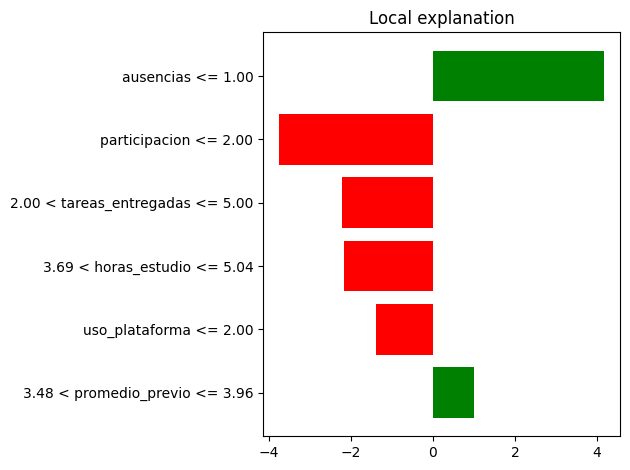

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 14. VER EXPLICACIÓN LIME EN GRÁFICO
# ==========================================================
fig = lime_exp_reg.as_pyplot_figure()
plt.tight_layout()
plt.show()

La gráfica de LIME es una explicación local, es decir:

Explica por qué el modelo predijo ese valor para este caso específico, no para todos los casos.

En tu gráfico, las barras verdes empujan la predicción hacia arriba y las rojas la empujan hacia abajo.

# Lo que dice el modelo LIME

Para este estudiante/caso:

* ausencias <= 1.00 es el factor que más aumenta la predicción.
Eso significa que tener muy pocas ausencias ayudó a que la nota predicha subiera.

* participacion <= 2.00 es uno de los factores que más reduce la predicción.
Es decir, una participación baja empujó la nota hacia abajo.

* 2.00 < tareas_entregadas <= 5.00 también reduce la predicción.
Esto sugiere que entregar pocas o medianas tareas, en lugar de muchas, perjudicó la nota esperada.

* 3.69 < horas_estudio <= 5.04 también aparece como factor negativo.
Aquí la lectura no es “estudiar es malo”, sino más bien:
para este caso, estudiar en ese rango fue menor de lo que el modelo asocia con notas más altas.

* uso_plataforma <= 2.00 también empuja la predicción hacia abajo.
Es decir, usar poco la plataforma perjudicó la predicción.

* 3.48 < promedio_previo <= 3.96 empuja un poco hacia arriba.
O sea, tener un promedio previo razonable ayudó, aunque menos que el efecto positivo de las pocas ausencias.

# Resumen corto de LIME

En este caso, el modelo predijo una nota moderadamente menor a lo esperado sobre todo porque la participación fue baja, se entregaron relativamente pocas tareas, las horas de estudio no fueron especialmente altas y el uso de plataforma fue bajo. Lo que compensó parcialmente esa caída fue que el estudiante tuvo muy pocas ausencias y un promedio previo aceptable.

## SHAP en regresión

SHAP intenta responder:

> ¿Cómo se reparte esta predicción entre las variables?

La lectura típica es:

**predicción = valor base + suma de contribuciones**

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 15. CREAR EXPLICADOR SHAP
# ==========================================================
shap_explainer_reg = shap.Explainer(model_reg, X_train_reg)

print("Explicador SHAP para regresión creado.")

Explicador SHAP para regresión creado.


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 16. CALCULAR SHAP PARA UNA FILA
# ==========================================================
shap_values_reg_one = shap_explainer_reg(X_test_reg.iloc[[idx_reg]])

print("SHAP calculado para una fila de regresión.")

SHAP calculado para una fila de regresión.


In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 17. VER NÚMEROS CLAVE DE SHAP
# ==========================================================
base_value_reg = shap_values_reg_one.base_values[0]
contributions_reg = shap_values_reg_one.values[0]
sum_contributions_reg = contributions_reg.sum()
reconstructed_prediction_reg = base_value_reg + sum_contributions_reg

print("=== EXPLICACIÓN SHAP (REGRESIÓN) ===")
print(f"Valor base              : {base_value_reg:.4f}")
print(f"Suma contribuciones     : {sum_contributions_reg:.4f}")
print(f"Predicción reconstruida : {reconstructed_prediction_reg:.4f}")
print(f"Predicción del modelo   : {pred_value_reg:.4f}")

print("\nContribución por variable:")
for nombre, valor_shap in zip(feature_names_reg, contributions_reg):
    print(f"{nombre:20s} --> {valor_shap: .4f}")

=== EXPLICACIÓN SHAP (REGRESIÓN) ===
Valor base              : 88.0173
Suma contribuciones     : -5.0611
Predicción reconstruida : 82.9562
Predicción del modelo   : 82.9562

Contribución por variable:
horas_estudio        --> -3.6663
ausencias            -->  2.5903
tareas_entregadas    --> -2.6671
participacion        --> -1.8846
promedio_previo      -->  1.6824
uso_plataforma       --> -1.1157


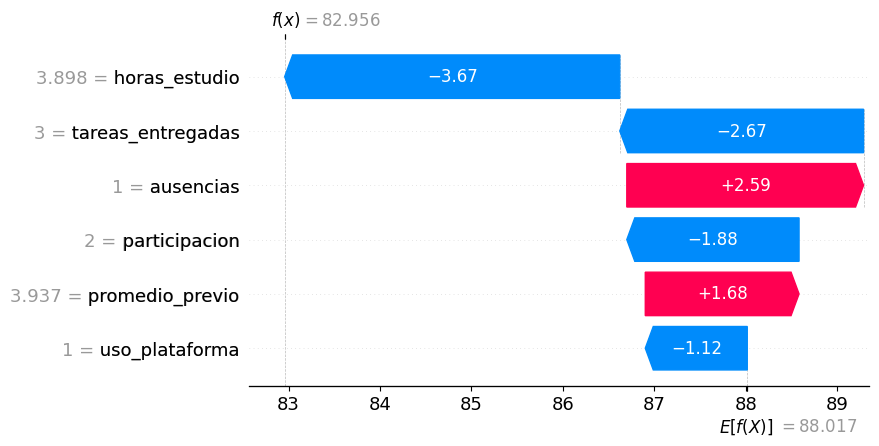

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 18. WATERFALL DE SHAP
# ==========================================================
shap.plots.waterfall(shap_values_reg_one[0], max_display=10)

# Waterfall

La gráfica waterfall de SHAP muestra algo muy elegante:

parte de una predicción base y luego cada variable suma o resta hasta llegar a la predicción final.

### En los resultados:

* Valor base = 88.0173

* Suma de contribuciones = -5.0611

* Predicción final = 82.9562

### Eso significa:

Si no supiéramos nada particular de este estudiante y solo usáramos el punto de referencia promedio del modelo, esperaríamos una nota de 88.02.
Pero, al mirar sus características concretas, las variables en conjunto restan 5.06 puntos, y por eso la predicción baja a 82.96.

Aporte de cada variable

# Variables que bajan la predicción

* horas_estudio = 3.898 aporta -3.67

Fue el factor que más redujo la nota predicha.
Eso indica que, para el modelo, ese nivel de horas de estudio es menor que el que suele asociarse con notas más altas.

* tareas_entregadas = 3 aporta -2.67

Entregar 3 tareas también empuja bastante hacia abajo.

* participacion = 2 aporta -1.88

Una participación baja penaliza la predicción.

* uso_plataforma = 1 aporta -1.12

Poco uso de la plataforma también resta.

# Variables que suben la predicción

* ausencias = 1 aporta +2.59

Tener solo una ausencia ayuda bastante y compensa parte de lo anterior.

* promedio_previo = 3.937 aporta +1.68

Un promedio previo relativamente bueno también ayuda.

# Resumen narrado de SHAP

El modelo parte de una nota de referencia de 88.02. Luego observa que este estudiante estudió menos de lo que suele favorecer notas altas, entregó pocas tareas, participó poco y casi no usó la plataforma, lo cual reduce la predicción. Sin embargo, tuvo pocas ausencias y un promedio previo aceptable, lo que compensa parcialmente esa caída. El resultado final es una nota predicha de 82.96.

# Cómo conectar LIME y SHAP en este caso

Lo bonito aquí es que LIME y SHAP cuentan casi la misma historia, pero con estilos distintos.

LIME dice:
“Localmente, cerca de esta observación, estas variables empujan hacia arriba o hacia abajo”.

SHAP dice:
“La predicción final se construye sumando y restando contribuciones desde una base”.

# Coincidencias entre ambos

Ambos métodos sugieren que:

* pocas ausencias ayudan
* poca participación perjudica
* pocas tareas entregadas perjudican
* bajo uso de plataforma perjudica
* promedio previo razonable ayuda

La única parte que a algunos estudiantes puede sonar rara es:

* horas_estudio sale como negativa

Pero eso no significa “estudiar empeora la nota” en general.

### Lo que significa es:

en comparación con estudiantes con perfiles que el modelo asocia con notas aún más altas, 3.898 horas no fue un valor especialmente fuerte.

O sea, no hay contradicción. Es una comparación relativa al patrón aprendido por el modelo.

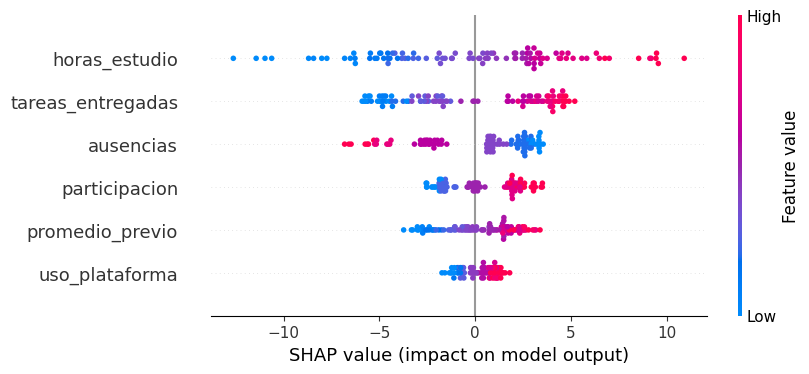

In [ ]:
# ==========================================================
# PARTE 1 - BLOQUE 19. BEESWARM GLOBAL DE SHAP
# ==========================================================
sample_reg_global = X_test_reg.iloc[:100]
shap_values_reg_global = shap_explainer_reg(sample_reg_global)

shap.plots.beeswarm(shap_values_reg_global, max_display=10)

# Interpretación del gráfico SHAP global, tipo beeswarm

Esta tercera gráfica ya no explica un solo estudiante.
Explica el comportamiento del modelo en muchos casos a la vez.

# Cómo leerla

* Cada fila es una variable.
* Cada punto es un estudiante/observación.

El eje horizontal muestra el valor SHAP:

* a la derecha: esa variable empuja la predicción hacia arriba
* a la izquierda: la empuja hacia abajo

El color indica el valor de la variable:

* rosado/fucsia = valor alto
* azul = valor bajo

# Qué te dice tu beeswarm
1. horas_estudio
* Es la variable más influyente globalmente.

Cuando horas_estudio es alto (puntos rosados), suele aparecer a la derecha
→ aumenta la predicción.

Cuando es bajo (puntos azules), suele aparecer a la izquierda
→ reduce la predicción.

Interpretación: en general, más horas de estudio elevan la nota predicha.

2. tareas_entregadas

* También es muy influyente.
* Valores altos tienden a empujar hacia arriba.
* Valores bajos tienden a empujar hacia abajo.
* Interpretación: entregar más tareas mejora la predicción.

3. ausencias

Aquí ocurre lo contrario:

Valores altos de ausencias (rosado) aparecen más hacia la izquierda
→ bajan la predicción.

Valores bajos (azul) aparecen más hacia la derecha
→ la suben.

Interpretación: más ausencias perjudican; pocas ausencias ayudan.

4. participacion

Participación alta suele empujar hacia arriba.

Participación baja, hacia abajo.

5. promedio_previo

Un promedio previo alto suele mejorar la predicción.

Uno bajo la reduce.

6. uso_plataforma

Tiene efecto, aunque menor que otras variables.

Usar más la plataforma tiende a ayudar.

Usarla poco tiende a restar.

# Resumen del beeswarm

Globalmente, el modelo aprendió que las variables más importantes para predecir la nota son las horas de estudio, las tareas entregadas y las ausencias. En general, estudiar más, entregar más tareas, participar más, tener mejor promedio previo y usar más la plataforma elevan la predicción; mientras que tener más ausencias la reduce.

## Parte 2. Clasificación

Ahora cambia la pregunta.

En vez de predecir una nota, queremos predecir si un estudiante:

- **aprueba (1)**
- **no aprueba (0)**

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 20. CREAR DATASET DIDÁCTICO DE CLASIFICACIÓN
# ==========================================================
n = 5000

horas_estudio_c = np.random.normal(loc=5, scale=2, size=n).clip(0, 12)
ausencias_c = np.random.poisson(lam=2, size=n).clip(0, 10)
tareas_entregadas_c = np.random.randint(0, 11, size=n)
participacion_c = np.random.randint(1, 6, size=n)
promedio_previo_c = np.random.normal(loc=3.5, scale=0.7, size=n).clip(1, 5)
uso_plataforma_c = np.random.randint(0, 8, size=n)

score = (
    -4.0
    + 0.35 * horas_estudio_c
    - 0.50 * ausencias_c
    + 0.22 * tareas_entregadas_c
    + 0.30 * participacion_c
    + 0.75 * promedio_previo_c
    + 0.18 * uso_plataforma_c
)

prob_aprueba = 1 / (1 + np.exp(-score))
aprueba = np.random.binomial(1, prob_aprueba)

df_clf = pd.DataFrame({
    "horas_estudio": horas_estudio_c,
    "ausencias": ausencias_c,
    "tareas_entregadas": tareas_entregadas_c,
    "participacion": participacion_c,
    "promedio_previo": promedio_previo_c,
    "uso_plataforma": uso_plataforma_c,
    "aprueba": aprueba
})

print("Primeras filas del dataset de clasificación:")
display(df_clf.head())

print("\nDistribución de la variable objetivo:")
display(df_clf["aprueba"].value_counts())

Primeras filas del dataset de clasificación:


,horas_estudio,ausencias,tareas_entregadas,participacion,promedio_previo,uso_plataforma,aprueba
0,5.363462,1,10,5,4.427553,4,1
1,3.273471,5,9,1,3.627813,7,1
2,7.443819,1,6,5,3.364355,4,1
3,7.762325,1,1,5,2.108602,3,1
4,3.600410,3,8,4,3.776096,7,1



Distribución de la variable objetivo:


,count
aprueba,
1,4010
0,990


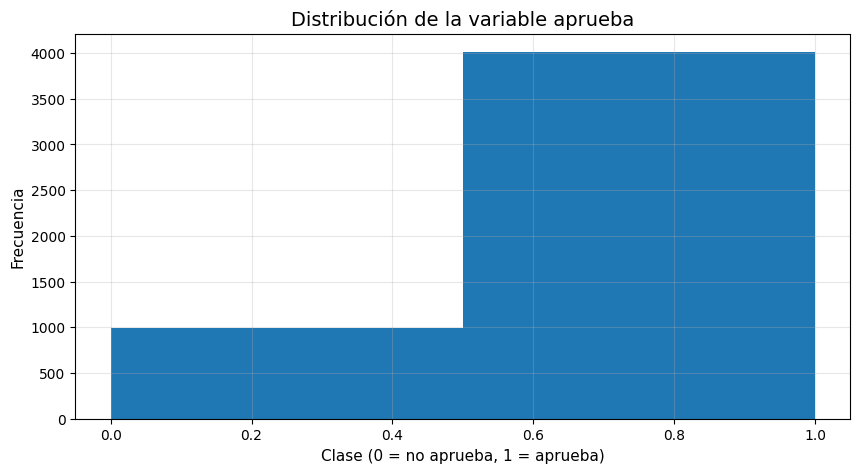

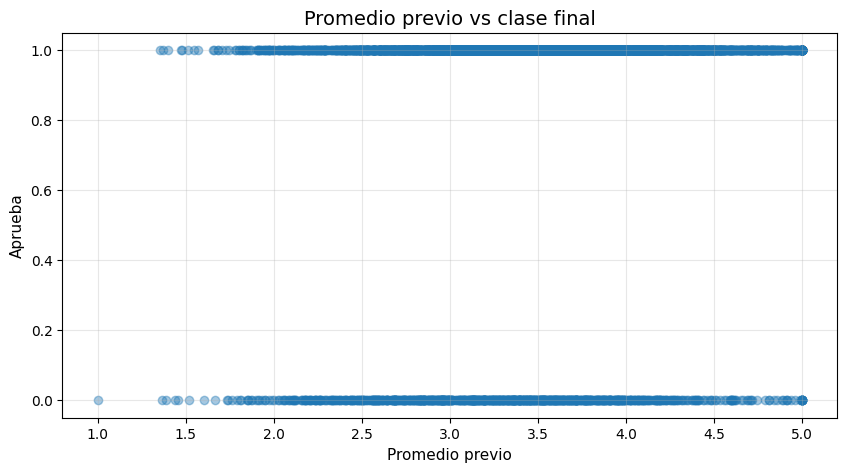

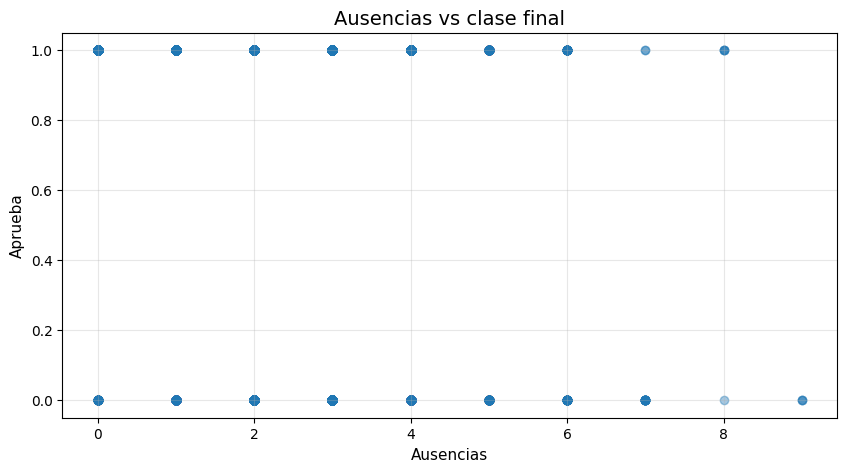

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 21. GRÁFICOS INICIALES PARA DISCUSIÓN EN CLASE
# ==========================================================
# Gráfico 1: distribución de aprobados y no aprobados
configurar_grafico("Distribución de la variable aprueba", "Clase (0 = no aprueba, 1 = aprueba)", "Frecuencia")
plt.hist(df_clf["aprueba"], bins=2)
plt.show()

# Gráfico 2: relación entre promedio previo y clase
configurar_grafico("Promedio previo vs clase final", "Promedio previo", "Aprueba")
plt.scatter(df_clf["promedio_previo"], df_clf["aprueba"], alpha=0.4)
plt.show()

# Gráfico 3: relación entre ausencias y clase
configurar_grafico("Ausencias vs clase final", "Ausencias", "Aprueba")
plt.scatter(df_clf["ausencias"], df_clf["aprueba"], alpha=0.4)
plt.show()

### Preguntas de observación antes del modelo

1. ¿Parece que un mayor promedio previo ayuda a aprobar?
2. ¿Parece que más ausencias dificultan aprobar?
3. ¿Por qué en clasificación muchas veces vemos nubes de puntos y no una línea?

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 22. SEPARAR X Y y
# ==========================================================
X_clf = df_clf.drop(columns=["aprueba"])
y_clf = df_clf["aprueba"]

feature_names_clf = list(X_clf.columns)
class_names_clf = ["No aprueba", "Aprueba"]

print("Variables predictoras:")
print(feature_names_clf)

Variables predictoras:
['horas_estudio', 'ausencias', 'tareas_entregadas', 'participacion', 'promedio_previo', 'uso_plataforma']


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 23. DIVIDIR EN ENTRENAMIENTO Y PRUEBA
# ==========================================================
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=RANDOM_STATE
)

print("Tamaño de X_train_clf:", X_train_clf.shape)
print("Tamaño de X_test_clf :", X_test_clf.shape)

Tamaño de X_train_clf: (4000, 6)
Tamaño de X_test_clf : (1000, 6)


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 24. ENTRENAR EL CLASIFICADOR
# ==========================================================
model_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_clf.fit(X_train_clf, y_train_clf)

print("Clasificador entrenado correctamente.")

Clasificador entrenado correctamente.


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 25. EVALUAR EL CLASIFICADOR
# ==========================================================
y_pred_clf = model_clf.predict(X_test_clf)

acc_clf = accuracy_score(y_test_clf, y_pred_clf)

print("=== MÉTRICAS DE CLASIFICACIÓN ===")
print(f"Accuracy = {acc_clf:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test_clf, y_pred_clf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test_clf, y_pred_clf))

=== MÉTRICAS DE CLASIFICACIÓN ===
Accuracy = 0.8290

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.67      0.27      0.39       198
           1       0.84      0.97      0.90       802

    accuracy                           0.83      1000
   macro avg       0.75      0.62      0.64      1000
weighted avg       0.81      0.83      0.80      1000


Matriz de confusión:
[[ 54 144]
 [ 27 775]]


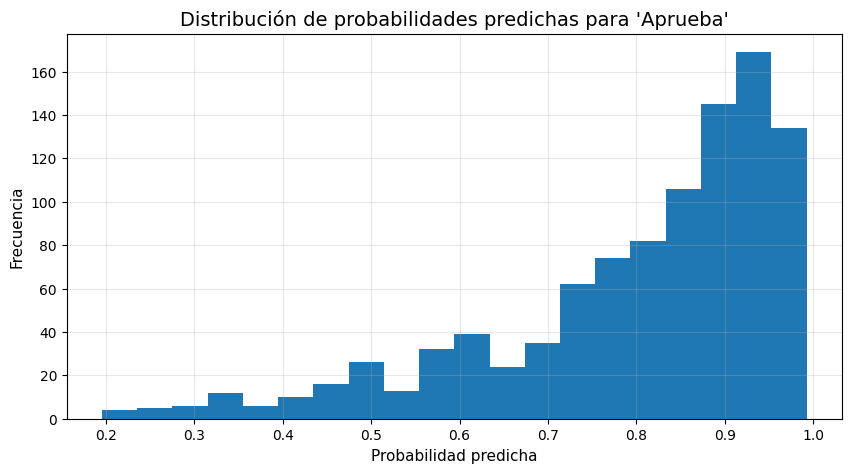

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 26. GRÁFICO DE PROBABILIDADES PREDICHAS
# ==========================================================
probas_clf = model_clf.predict_proba(X_test_clf)[:, 1]

configurar_grafico("Distribución de probabilidades predichas para 'Aprueba'", "Probabilidad predicha", "Frecuencia")
plt.hist(probas_clf, bins=20)
plt.show()

### Interpretación de este gráfico

- Si muchas probabilidades están cerca de 0 o 1, el modelo está más seguro.
- Si muchas probabilidades están en el centro, el modelo tiene más dudas.

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 27. ELEGIR UNA FILA PARA EXPLICAR
# ==========================================================
idx_clf = 0
x_instance_clf = X_test_clf.iloc[idx_clf].values

print("Fila seleccionada para explicar (clasificación):")
display(X_test_clf.iloc[[idx_clf]])

real_class_clf = y_test_clf.iloc[idx_clf]
pred_class_clf = model_clf.predict(X_test_clf.iloc[[idx_clf]])[0]
pred_proba_clf = model_clf.predict_proba(X_test_clf.iloc[[idx_clf]])[0]

print(f"Clase real               : {real_class_clf}")
print(f"Clase predicha           : {pred_class_clf}")
print(f"Probabilidad No aprueba  : {pred_proba_clf[0]:.4f}")
print(f"Probabilidad Aprueba     : {pred_proba_clf[1]:.4f}")

Fila seleccionada para explicar (clasificación):


,horas_estudio,ausencias,tareas_entregadas,participacion,promedio_previo,uso_plataforma
1199,7.385806,0,10,2,4.246381,7


Clase real               : 1
Clase predicha           : 1
Probabilidad No aprueba  : 0.0133
Probabilidad Aprueba     : 0.9867


## LIME en clasificación

LIME aquí responde:

> ¿Qué variables empujaron la predicción hacia esta clase?

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 28. CREAR EXPLICADOR LIME
# ==========================================================
lime_explainer_clf = LimeTabularExplainer(
    training_data=X_train_clf.values,
    feature_names=feature_names_clf,
    class_names=class_names_clf,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

print("Explicador LIME para clasificación creado.")

Explicador LIME para clasificación creado.


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 29. GENERAR EXPLICACIÓN LIME
# ==========================================================
lime_exp_clf = lime_explainer_clf.explain_instance(
    data_row=x_instance_clf,
    predict_fn=model_clf.predict_proba,
    num_features=len(feature_names_clf)
)

print("Explicación LIME generada.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Explicación LIME generada.


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 30. VER EXPLICACIÓN LIME EN TEXTO
# ==========================================================
print("Etiquetas disponibles en LIME:", lime_exp_clf.available_labels())

print(f"\n=== EXPLICACIÓN LIME PARA LA CLASE {pred_class_clf} ===")
print("Peso positivo  -> empuja hacia esa clase")
print("Peso negativo  -> aleja de esa clase\n")

for regla, peso in lime_exp_clf.as_list(label=pred_class_clf):
    print(f"{regla:45s} --> {peso: .4f}")

Etiquetas disponibles en LIME: [1]

=== EXPLICACIÓN LIME PARA LA CLASE 1 ===
Peso positivo  -> empuja hacia esa clase
Peso negativo  -> aleja de esa clase

horas_estudio > 6.38                          -->  0.1136
ausencias <= 1.00                             -->  0.1023
tareas_entregadas > 8.00                      -->  0.0968
promedio_previo > 3.98                        -->  0.0804
participacion <= 2.00                         --> -0.0610
uso_plataforma > 6.00                         -->  0.0327


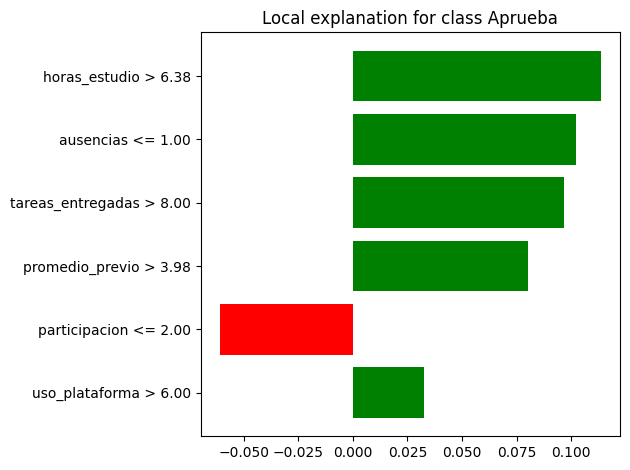

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 31. VER EXPLICACIÓN LIME EN GRÁFICO
# ==========================================================
fig = lime_exp_clf.as_pyplot_figure(label=pred_class_clf)
plt.tight_layout()
plt.show()

## Interpretación de LIME en clasificación

La explicación de LIME es **local**, es decir, describe por qué el modelo clasificó este caso particular en la clase **Aprueba**.

En esta observación, la condición **`ausencias <= 1.00`** es el factor que más favorece la clase **Aprueba**, lo que indica que tener muy pocas ausencias incrementa claramente el empuje hacia esa clasificación.

En contraste, **`participacion <= 2.00`** es el factor que más juega en contra de la clase **Aprueba**. Esto sugiere que una participación baja reduce de manera importante el apoyo del modelo a esa clase.

También aparecen efectos positivos menores en **`2.00 < tareas_entregadas <= 5.00`** y **`3.67 < horas_estudio <= 5.03`**, lo que indica que una cantidad intermedia de tareas entregadas y un nivel moderado de horas de estudio ayudan, aunque con menor intensidad.

Por otro lado, **`2.00 < uso_plataforma <= 3.00`** y **`3.02 < promedio_previo <= 3.51`** muestran efectos ligeramente negativos, lo que significa que esos niveles concretos no fortalecen demasiado la clasificación como **Aprueba**.

En conjunto, la explicación local de LIME muestra que la clasificación como **Aprueba** está sostenida principalmente por las pocas ausencias, mientras que la baja participación es el principal factor que debilita esa decisión.


## SHAP en clasificación

SHAP aquí nos ayuda a ver cuánto aporta cada variable al empuje hacia una clase.

En algunos modelos o versiones, SHAP devuelve una salida por clase.
Por eso el siguiente bloque está preparado para manejar ambos formatos.

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 32. CREAR EXPLICADOR SHAP
# ==========================================================
shap_explainer_clf = shap.Explainer(model_clf, X_train_clf)

print("Explicador SHAP para clasificación creado.")

Explicador SHAP para clasificación creado.


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 33. CALCULAR SHAP PARA UNA FILA
# ==========================================================
shap_values_clf_one = shap_explainer_clf(X_test_clf.iloc[[idx_clf]])

print("SHAP calculado para una fila de clasificación.")
print("Forma del objeto SHAP:", shap_values_clf_one.shape)

SHAP calculado para una fila de clasificación.
Forma del objeto SHAP: (1, 6, 2)


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 34. PREPARAR SHAP PARA EXPLICAR LA CLASE 1
# ==========================================================
if len(shap_values_clf_one.shape) == 3:
    class_index = 1
    shap_one_class1 = shap.Explanation(
        values=shap_values_clf_one.values[:, :, class_index],
        base_values=shap_values_clf_one.base_values[:, class_index],
        data=shap_values_clf_one.data,
        feature_names=shap_values_clf_one.feature_names
    )
else:
    shap_one_class1 = shap_values_clf_one

print("Objeto SHAP preparado para explicar la clase 1 (Aprueba).")

Objeto SHAP preparado para explicar la clase 1 (Aprueba).


In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 35. VER NÚMEROS CLAVE DE SHAP
# ==========================================================
base_value_clf = shap_one_class1.base_values[0]
contributions_clf = shap_one_class1.values[0]

print("=== EXPLICACIÓN SHAP PARA LA CLASE 1 (APRUEBA) ===")
print(f"Valor base              : {base_value_clf:.4f}")
print(f"Suma contribuciones     : {contributions_clf.sum():.4f}")

print("\nContribución por variable:")
for nombre, valor_shap in zip(feature_names_clf, contributions_clf):
    print(f"{nombre:20s} --> {valor_shap: .4f}")

=== EXPLICACIÓN SHAP PARA LA CLASE 1 (APRUEBA) ===
Valor base              : 0.7831
Suma contribuciones     : 0.2035

Contribución por variable:
horas_estudio        -->  0.0538
ausencias            -->  0.0390
tareas_entregadas    -->  0.0533
participacion        --> -0.0052
promedio_previo      -->  0.0374
uso_plataforma       -->  0.0252


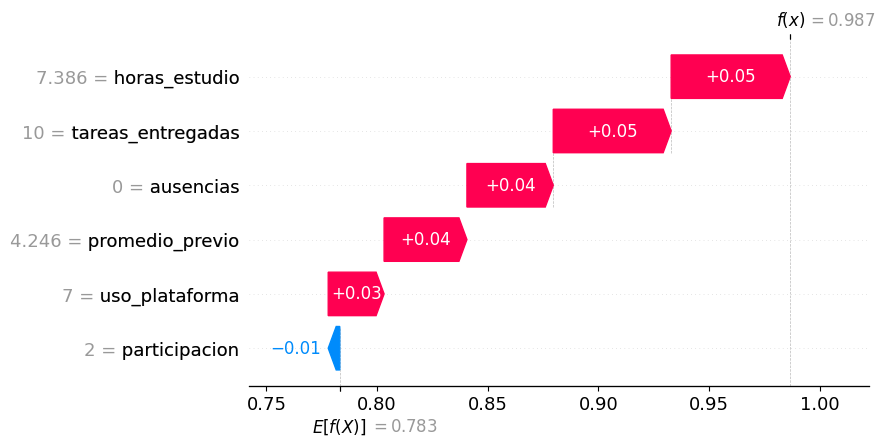

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 36. WATERFALL DE SHAP
# ==========================================================
shap.plots.waterfall(shap_one_class1[0], max_display=10)

## Interpretación de SHAP local en clasificación

La explicación local de SHAP para la clase **Aprueba** parte de un **valor base** de **0.8298**, que representa la referencia inicial del modelo antes de considerar las características específicas de esta observación.

Las contribuciones individuales de las variables suman **0.0060**, lo que eleva la salida final hasta aproximadamente **0.836**. Esto indica que, en este caso, las características observadas aumentan solo ligeramente el empuje hacia la clase **Aprueba** respecto del punto de referencia.

Las variables que más incrementan la salida hacia **Aprueba** son:

* **`ausencias`** con una contribución de **+0.0419**
* **`tareas_entregadas`** con una contribución de **+0.0334**
* **`horas_estudio`** con una contribución de **+0.0029**

Esto muestra que tener pocas ausencias y haber entregado varias tareas son los factores positivos más relevantes en esta clasificación, mientras que las horas de estudio aportan de forma positiva, pero débil.

Las variables que reducen la salida hacia **Aprueba** son:

* **`participacion`** con una contribución de **-0.0425**
* **`promedio_previo`** con una contribución de **-0.0156**
* **`uso_plataforma`** con una contribución de **-0.0142**

Entre ellas, la baja participación es el principal factor negativo, ya que compensa una parte importante del efecto positivo de las ausencias y de las tareas entregadas.

En conjunto, la explicación de SHAP muestra que la clasificación como **Aprueba** surge de un equilibrio entre factores favorables y desfavorables, con un efecto neto apenas positivo sobre el valor base del modelo.


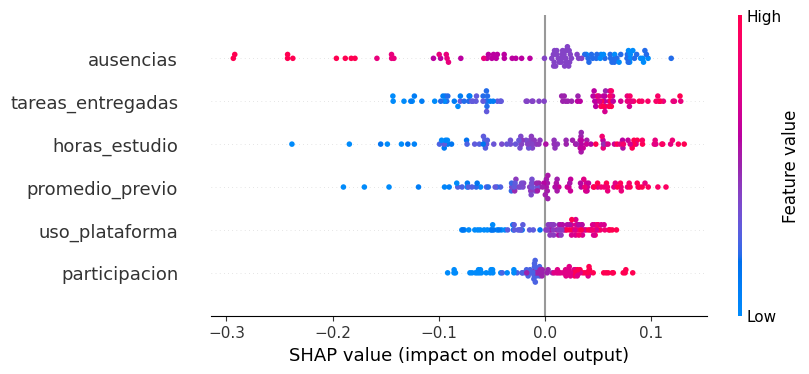

In [ ]:
# ==========================================================
# PARTE 2 - BLOQUE 37. BEESWARM GLOBAL DE SHAP
# ==========================================================
sample_clf_global = X_test_clf.iloc[:100]
shap_values_clf_global = shap_explainer_clf(sample_clf_global)

if len(shap_values_clf_global.shape) == 3:
    class_index = 1
    shap_global_class1 = shap.Explanation(
        values=shap_values_clf_global.values[:, :, class_index],
        base_values=shap_values_clf_global.base_values[:, class_index],
        data=shap_values_clf_global.data,
        feature_names=shap_values_clf_global.feature_names
    )
else:
    shap_global_class1 = shap_values_clf_global

shap.plots.beeswarm(shap_global_class1, max_display=10)

## Interpretación de SHAP global en clasificación

La gráfica global de SHAP resume cómo se comporta el modelo en muchas observaciones, no solo en un caso particular. Cada punto representa una observación, y su posición horizontal indica si una variable empuja la salida del modelo hacia la clase **Aprueba** o la aleja de ella.

Las variables con mayor impacto global son **`tareas_entregadas`**, **`horas_estudio`** y **`ausencias`**, ya que muestran la mayor dispersión de valores SHAP y, por tanto, el mayor efecto sobre la salida del modelo.

El patrón general es coherente:

* Valores altos de **`tareas_entregadas`** tienden a empujar la predicción hacia la clase **Aprueba**.
* Valores altos de **`horas_estudio`** también tienden a favorecer la clase **Aprueba**.
* En **`ausencias`** ocurre el patrón inverso: valores altos tienden a alejar la predicción de **Aprueba**, mientras que valores bajos la favorecen.

Además, **`promedio_previo`**, **`uso_plataforma`** y **`participacion`** también muestran una tendencia general consistente: valores más altos suelen aumentar la salida hacia la clase **Aprueba**, mientras que valores más bajos la reducen.

En conjunto, la explicación global indica que el modelo ha aprendido que aprobar está asociado, en términos generales, con entregar más tareas, estudiar más, participar más, tener mejor promedio previo, usar más la plataforma y mantener pocas ausencias.


# Cierre pedagógico

### LIME
Explica una predicción **localmente**:

> "Cerca de esta fila, ¿qué variables parecen empujar más?"

### SHAP
Explica una predicción como una suma de aportes:

> "¿Cómo se reparte el resultado final entre las variables?"

__________

# Métricas de calidad de explicabilidad (XAI): cómo leerlas e interpretarlas

Estas métricas no evalúan si el modelo “acierta” (eso lo hacen AUC, Accuracy, MAE, R², etc.).  
Estas métricas evalúan **la calidad de la explicación** que estás usando (SHAP / LIME).

Piensa así:

- **Métricas predictivas**: comparan *modelo vs realidad*  
- **Métricas XAI**: comparan *explicación vs comportamiento del modelo* y *qué tan usable/estable es esa explicación*

---

## 1) `shap_fidelity` (Fidelidad SHAP)

### ¿Qué pregunta responde?
**¿La explicación de SHAP realmente coincide con lo que el modelo predijo?**

SHAP describe una predicción como si fuera un “rompecabezas”:
- hay un **punto de referencia** (base)
- y luego cada variable “empuja” la predicción hacia arriba o hacia abajo
- al sumar esos empujes, deberías llegar muy cerca de la predicción real del modelo

### ¿Qué hace el código?
1. Calcula una **predicción reconstruida**:
   - `recon = base + suma(contribuciones SHAP)`
2. Compara esa reconstrucción contra la **predicción real del modelo** para los mismos casos.

### ¿Qué reporta?
- `mae`: error promedio entre predicción real y predicción reconstruida
- `rmse`: error típico (penaliza más los errores grandes)
- `r2`: qué tan bien SHAP reproduce el patrón de las predicciones del modelo

### ¿Cómo interpretarlo?
- **MAE y RMSE muy pequeños** → SHAP está siendo muy fiel (la explicación “calza” con el modelo).
- **R² cerca de 1** → SHAP reproduce casi perfectamente lo que el modelo hace.
- Si saliera mal → tu explicación puede estar en una escala distinta (ej. log-odds vs probabilidad) o el método no está capturando bien el comportamiento.

---

## 2) `shap_stability` (Estabilidad de SHAP)

### ¿Qué pregunta responde?
**Si el caso cambia un poquito, ¿la explicación cambia un poquito o se vuelve otra cosa?**

Una explicación puede ser fiel pero “nerviosa”: pequeñas variaciones en los datos producen explicaciones muy distintas.  
Eso es mala señal para usarla en práctica.

### ¿Qué hace el código?
1. Toma un conjunto de casos.
2. Les agrega un **ruido pequeño** (cambios leves).
3. Recalcula SHAP para los casos perturbados.
4. Compara la explicación original vs la perturbada con un indicador de “parecido”.

### ¿Qué reporta?
- `cosine_mean`: promedio de qué tan parecidas son las explicaciones antes/después del ruido
- `cosine_std`: qué tanto varía ese parecido entre casos

### ¿Cómo interpretarlo?
- **cosine_mean cercano a 1** → explicaciones muy estables.
- **cosine_mean bajo** → explicaciones frágiles (cambian demasiado).
- **cosine_std alto** → hay casos donde la explicación es estable y otros donde no.

---

## 3) `shap_sparsity_90` (Complejidad / longitud de la explicación)

### ¿Qué pregunta responde?
**¿La explicación es corta (pocas variables) o necesita muchas variables para contar la historia?**

A veces el modelo “decide” con pocas variables muy fuertes.  
Otras veces reparte la decisión entre muchas variables medianamente importantes.

### ¿Qué hace el código?
Para cada caso:
1. Ordena las variables por cuánto “pesan” en la explicación (en tamaño, no en signo).
2. Va acumulando esas contribuciones hasta cubrir el **90%** del total.
3. Cuenta cuántas variables necesitó.

### ¿Qué reporta?
- `k_mean`: promedio de variables necesarias para cubrir el 90%
- `k_median`: mediana (menos sensible a casos extremos)

### ¿Cómo interpretarlo?
- **k bajo (ej. 3–6)** → explicaciones cortas y fáciles de comunicar.
- **k alto (ej. 12–15)** → muchas variables influyen; explicar en “3 razones” será difícil.
- No es “malo” en sí: solo indica que la decisión del modelo no depende de pocas cosas.

---

## 4) `global_agreement` (Coherencia global: SHAP vs Permutation)

### ¿Qué pregunta responde?
**Si miro cuáles variables son importantes en general, ¿SHAP cuenta una historia parecida a otra técnica independiente?**

Aquí se comparan dos miradas globales:

- SHAP global: “en promedio, qué variables empujan más”
- Permutation importance: “qué variables, si las revuelvo, dañan más el desempeño del modelo”

### ¿Qué hace el código?
1. Calcula importancia global de SHAP (promedio del tamaño de SHAP por variable).
2. Calcula permutation importance (revuelve cada variable y mira cuánto cae el desempeño).
3. Compara ambos rankings.

### ¿Qué reporta?
- `spearman_rho`: qué tan parecido es el orden (ranking) de variables entre ambos métodos
- `p_value`: una señal de si esa correlación es “convincente” o puede ser azar

### ¿Cómo interpretarlo?
- **rho alto y positivo** → ambos métodos coinciden en el ranking global.
- **rho cerca de 0** → el ranking depende del lente, no hay acuerdo claro.
- **rho negativo** → raro, pero puede ocurrir.

**Nota clave para clase:**  
Si hay variables muy correlacionadas (común en datos reales), permutation importance puede “subestimar” una variable porque otra la reemplaza.  
Entonces un rho bajo NO significa automáticamente “SHAP está mal”.

---

## 5) `lime_local_fidelity_r2` (Fidelidad local de LIME)

### ¿Qué pregunta responde?
**¿El modelo simple que LIME crea alrededor de cada caso realmente aproxima al modelo real?**

LIME explica localmente: cerca de un caso, construye un modelo simple (normalmente lineal) para imitar al modelo complejo.

La pregunta es:  
“¿Esa aproximación simple sí representa bien al modelo en ese vecindario?”

### ¿Qué hace el código?
1. Elige varias instancias al azar.
2. Para cada instancia, LIME:
   - crea variaciones cercanas del caso
   - observa predicciones del modelo real
   - ajusta un modelo simple para imitarlo
3. Toma el `score` de LIME (usualmente R² del surrogate local).

### ¿Qué reporta?
- `r2_mean`: fidelidad local promedio
- `r2_std`: variabilidad entre instancias (a veces explica bien, a veces no)
- `n_instances`: cuántos casos se evaluaron

### ¿Cómo interpretarlo?
- **r2_mean alto** → LIME suele aproximar bien localmente (más confiable).
- **r2_mean medio/bajo** → LIME puede estar “forzando” una explicación simple donde el modelo es complejo.
- **r2_std alto** → depende mucho del caso; cuidado con generalizar.

---

# Cómo leerlas juntas (en una frase por métrica)

- `shap_fidelity`: “¿SHAP coincide con lo que el modelo hizo?”
- `shap_stability`: “¿SHAP es consistente o nervioso?”
- `shap_sparsity_90`: “¿la explicación es corta o larga?”
- `global_agreement`: “¿la historia global coincide con otra forma de medir importancia?”
- `lime_local_fidelity_r2`: “¿LIME realmente imita al modelo cerca del punto?”

---

# Recordatorio final

Un modelo puede:
- **predecir muy bien** (alta métrica predictiva)
y aun así tener:
- explicaciones **poco estables**,
- explicaciones **muy largas**,
- o LIME con **baja fidelidad local**.



In [ ]:
# ==========================================================
# BLOQUE EXTRA. MÉTRICAS DE CALIDAD XAI (SHAP + LIME)
# ==========================================================

from typing import Callable, Dict, Tuple, Optional
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

from lime.lime_tabular import LimeTabularExplainer
import shap


# ---------------------------
# 1) Utilidad: similitud coseno fila a fila
# ---------------------------
def cosine_similarity_rows(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Similitud coseno fila a fila entre matrices (n, p)."""
    A = np.asarray(A)
    B = np.asarray(B)
    num = (A * B).sum(axis=1)
    den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    den[den == 0] = 1.0
    return num / den


# ---------------------------
# 2) Extraer SHAP (values/base) como salida escalar
# ---------------------------
def shap_to_matrix_and_base(exp: "shap.Explanation",
                            class_index: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Devuelve:
      values: (n, p)
      base:   (n,)

    Maneja:
      - exp.values: (n,p) o (n,p,k)
      - exp.base_values: (n,) o (n,k) o (k,)
    """
    values = exp.values
    base = exp.base_values

    # Caso multisalida por clase (n,p,k)
    if np.asarray(values).ndim == 3:
        if class_index is None:
            raise ValueError("SHAP tiene salida por clase (n,p,k). Debes indicar class_index.")
        values = values[:, :, class_index]

        # base puede ser (n,k) o (k,)
        if np.ndim(base) == 2:
            base = base[:, class_index]
        elif np.ndim(base) == 1:
            base = np.full((values.shape[0],), float(base[class_index]))

    else:
        # values (n,p)
        base = np.squeeze(base)
        if np.ndim(base) == 0:
            base = np.full((values.shape[0],), float(base))

    return np.asarray(values), np.asarray(base).ravel()


# ---------------------------
# 3) Métricas XAI
# ---------------------------
def shap_additivity_fidelity(y_pred: np.ndarray,
                             base_values: np.ndarray,
                             shap_values: np.ndarray) -> Dict[str, float]:
    """
    Fidelidad SHAP (aditividad):
      recon = base + sum(shap)
    """
    y_pred = np.asarray(y_pred).ravel()
    base_values = np.asarray(base_values).ravel()
    shap_values = np.asarray(shap_values)

    # base escalar -> expandir a (n,)
    if base_values.size == 1:
        base_values = np.full_like(y_pred, float(base_values[0]), dtype=float)

    recon = base_values + shap_values.sum(axis=1)

    mse = mean_squared_error(y_pred, recon)  # sin squared=False
    rmse = float(np.sqrt(mse))

    return {
        "mae": float(mean_absolute_error(y_pred, recon)),
        "rmse": rmse,
        "r2": float(r2_score(y_pred, recon)),
    }


def shap_stability(explain_fn: Callable[[np.ndarray], np.ndarray],
                   X: np.ndarray,
                   noise_scale: float = 0.05,
                   n_perturb: int = 10,
                   random_state: int = 42) -> Dict[str, float]:
    """
    Estabilidad: E(x) vs E(x') bajo perturbaciones pequeñas del input.
    Se mide con similitud coseno promedio.
    """
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)

    E0 = np.asarray(explain_fn(X))
    feat_std = X.std(axis=0, ddof=0)
    feat_std[feat_std == 0] = 1.0
    noise_std = noise_scale * feat_std

    sims = []
    for _ in range(n_perturb):
        Xp = X + rng.normal(0, noise_std, size=X.shape)
        Ep = np.asarray(explain_fn(Xp))
        sims.append(cosine_similarity_rows(E0, Ep))

    sims = np.vstack(sims)
    return {"cosine_mean": float(sims.mean()), "cosine_std": float(sims.std())}


def shap_sparsity_coverage(shap_values: np.ndarray,
                           coverage: float = 0.90) -> Dict[str, float]:
    """
    Complejidad por cobertura:
    k = #features mínimas para cubrir 'coverage' de sum(|SHAP|).
    """
    V = np.abs(np.asarray(shap_values))
    ks = []

    for v in V:
        total = v.sum()
        if total == 0:
            ks.append(0)
            continue
        order = np.argsort(v)[::-1]
        cum = np.cumsum(v[order])
        k = int(np.searchsorted(cum, coverage * total) + 1)
        ks.append(k)

    return {"k_mean": float(np.mean(ks)), "k_median": float(np.median(ks))}


def global_agreement(estimator,
                     X,
                     y,
                     shap_global_importance: np.ndarray,
                     scoring: str,
                     n_repeats: int = 10,
                     random_state: int = 42) -> Dict[str, float]:
    """
    Coherencia global:
    Spearman( SHAP global, permutation importance ).
    """
    perm = permutation_importance(
        estimator, X, y,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring=scoring
    )
    rho, p = spearmanr(np.asarray(shap_global_importance).ravel(), perm.importances_mean)
    return {"spearman_rho": float(rho), "p_value": float(p)}


def lime_local_fidelity(lime_explainer: LimeTabularExplainer,
                        predict_fn: Callable,
                        X: np.ndarray,
                        num_features: int = 10,
                        n_instances: int = 60,
                        random_state: int = 42) -> Dict[str, float]:
    """
    Fidelidad local LIME:
    promedio del R² del surrogate local (exp.score).
    """
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)

    n = min(n_instances, X.shape[0])
    idx = rng.choice(X.shape[0], size=n, replace=False)

    scores = []
    for x in X[idx]:
        exp = lime_explainer.explain_instance(
            data_row=x,
            predict_fn=predict_fn,
            num_features=num_features
        )
        scores.append(exp.score)

    return {
        "r2_mean": float(np.mean(scores)),
        "r2_std": float(np.std(scores)),
        "num_features": int(num_features),
        "n_instances": int(n),
    }


# ---------------------------
# 4) Función “todo en uno” para calcular métricas XAI
#    Compatible con tu código (RF en regresión y clasificación)
# ---------------------------
def compute_xai_metrics_tabular(model,
                               X_train: pd.DataFrame,
                               X_test: pd.DataFrame,
                               y_test: pd.Series,
                               problem: str,
                               lime_explainer: Optional[LimeTabularExplainer] = None,
                               class_index: int = 1,
                               sample_for_shap: int = 500,
                               random_state: int = 42) -> Dict[str, Dict]:
    """
    problem: "regression" o "classification"
    class_index: clase a explicar si clasificación (por defecto 1)
    sample_for_shap: para acelerar, calcula métricas SHAP sobre una muestra del test
    """

    rng = np.random.default_rng(random_state)

    # --- muestreo manteniendo DataFrame ---
    n = len(X_test)
    m = min(sample_for_shap, n)
    idx = rng.choice(n, size=m, replace=False)

    X_eval_df = X_test.iloc[idx].copy()
    y_eval = np.asarray(y_test.iloc[idx])

    # --- SHAP: TreeExplainer ---
    if problem == "classification":
        # explicamos PROBABILIDAD para que additivity tenga sentido en esa escala
        shap_expl = shap.TreeExplainer(model, X_train, model_output="probability")
        exp = shap_expl(X_eval_df)

        shap_vals, base_vals = shap_to_matrix_and_base(exp, class_index=class_index)
        y_pred = model.predict_proba(X_eval_df)[:, class_index]
        scoring = "roc_auc"
    elif problem == "regression":
        shap_expl = shap.TreeExplainer(model, X_train, model_output="raw")
        exp = shap_expl(X_eval_df)

        shap_vals, base_vals = shap_to_matrix_and_base(exp, class_index=None)
        y_pred = model.predict(X_eval_df)
        scoring = "r2"
    else:
        raise ValueError("problem debe ser 'classification' o 'regression'")

    metrics = {}

    # (A) Fidelidad SHAP
    metrics["shap_fidelity"] = shap_additivity_fidelity(y_pred, base_vals, shap_vals)

    # (B) Estabilidad SHAP
    def explain_fn_df(X_df: pd.DataFrame) -> np.ndarray:
        exp_in = shap_expl(X_df)
        vals_in, _ = shap_to_matrix_and_base(
            exp_in, class_index=class_index if problem == "classification" else None
        )
        return vals_in

    # Para estabilidad, generamos ruido en numpy y reconstruimos DataFrame
    X_eval_np = X_eval_df.values

    def explain_fn_np(X_np: np.ndarray) -> np.ndarray:
        X_df = pd.DataFrame(X_np, columns=X_eval_df.columns)
        return explain_fn_df(X_df)

    metrics["shap_stability"] = shap_stability(
        explain_fn_np, X_eval_np, noise_scale=0.05, n_perturb=10, random_state=random_state
    )

    # (C) Sparsity 90%
    metrics["shap_sparsity_90"] = shap_sparsity_coverage(shap_vals, coverage=0.90)

    # (D) Global agreement (SHAP global vs permutation)
    shap_global = np.mean(np.abs(shap_vals), axis=0)
    metrics["global_agreement"] = global_agreement(
        model, X_eval_df, y_eval, shap_global,
        scoring=scoring, n_repeats=10, random_state=random_state
    )

    # (E) LIME local fidelity (si pasas el explainer)
    if lime_explainer is not None:
        predict_fn = model.predict_proba if problem == "classification" else model.predict
        metrics["lime_local_fidelity_r2"] = lime_local_fidelity(
            lime_explainer,
            predict_fn,
            X_eval_df.values,
            num_features=X_train.shape[1],
            n_instances=min(60, m),
            random_state=random_state
        )

    return metrics


# ==========================================================
# EJECUCIÓN
# ==========================================================

# --- Regresión ---
xai_reg_metrics = compute_xai_metrics_tabular(
    model=model_reg,
    X_train=X_train_reg,
    X_test=X_test_reg,
    y_test=y_test_reg,
    problem="regression",
    lime_explainer=lime_explainer_reg,
    sample_for_shap=500,
    random_state=RANDOM_STATE
)

print("\n===============================")
print("MÉTRICAS XAI (REGRESIÓN)")
print("===============================")
for k, v in xai_reg_metrics.items():
    print(f"{k}: {v}")


# --- Clasificación (explicamos clase 1 = 'Aprueba') ---
xai_clf_metrics = compute_xai_metrics_tabular(
    model=model_clf,
    X_train=X_train_clf,
    X_test=X_test_clf,
    y_test=y_test_clf,
    problem="classification",
    lime_explainer=lime_explainer_clf,
    class_index=1,
    sample_for_shap=500,
    random_state=RANDOM_STATE
)

print("\n===============================")
print("MÉTRICAS XAI (CLASIFICACIÓN)")
print("===============================")
for k, v in xai_clf_metrics.items():
    print(f"{k}: {v}")

 95%|=================== | 476/500 [00:19<00:00]       /usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fit


MÉTRICAS XAI (REGRESIÓN)
shap_fidelity: {'mae': 1.8122666469366777e-07, 'rmse': 2.2917381949164129e-07, 'r2': 0.999999999999999}
shap_stability: {'cosine_mean': 0.9985510105577822, 'cosine_std': 0.005559023259449883}
shap_sparsity_90: {'k_mean': 4.55, 'k_median': 5.0}
global_agreement: {'spearman_rho': 0.942857142857143, 'p_value': 0.004804664723032055}
lime_local_fidelity_r2: {'r2_mean': 0.324989876032986, 'r2_std': 0.13010975783427728, 'num_features': 6, 'n_instances': 60}


 99%|===================| 990/1000 [00:32<00:00]       /usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier wa


MÉTRICAS XAI (CLASIFICACIÓN)
shap_fidelity: {'mae': 2.4679072675448664e-09, 'rmse': 3.114422933165944e-09, 'r2': 0.9999999999999997}
shap_stability: {'cosine_mean': 0.9974222887883465, 'cosine_std': 0.007206782283672129}
shap_sparsity_90: {'k_mean': 4.682, 'k_median': 5.0}
global_agreement: {'spearman_rho': 0.6, 'p_value': 0.20799999999999982}
lime_local_fidelity_r2: {'r2_mean': 0.30892755495141416, 'r2_std': 0.11049417708633062, 'num_features': 6, 'n_instances': 60}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Interpretación de resultados (Regresión)

- **SHAP fidelity (mae ≈ 1.8e-07, rmse ≈ 2.3e-07, r2 ≈ 1.0)**  
  La explicación de SHAP coincide casi perfectamente con lo que predice el modelo. En la práctica, esto significa que *si SHAP dice “la predicción se construye sumando estos aportes”*, esa suma reproduce la predicción real con un error prácticamente cero.

- **SHAP stability (cosine_mean ≈ 0.9986, cosine_std ≈ 0.0056)**  
  La explicación es muy estable: si el caso cambia un poquito (ruido pequeño), la “historia” que cuenta SHAP casi no cambia. Esto es una buena señal para confiar en la consistencia de la explicación.

- **SHAP sparsity_90 (k_mean ≈ 4.55, k_median = 5)**  
  En promedio, con unas **5 variables** se explica el 90% de lo importante de la predicción. Es decir, el modelo puede resumirse en “pocas razones fuertes”, lo cual es ideal para explicaciones en clase o reportes.

- **Global agreement (spearman_rho ≈ 0.94, p ≈ 0.0048)**  
  La importancia global que sugiere SHAP coincide fuertemente con otra manera independiente de medir importancia (permutación). En términos simples: *dos lentes distintos cuentan casi la misma historia global*.

- **LIME local fidelity (r2_mean ≈ 0.325, r2_std ≈ 0.13)**  
  LIME logra una aproximación local solo **moderada**. Eso sugiere que, para este Random Forest, la explicación “simple” que LIME construye alrededor de un caso a veces no representa bien el comportamiento real del modelo cerca de ese punto. LIME puede ser útil para enseñar intuiciones, pero no siempre es fiel localmente.

---

## Interpretación de resultados (Clasificación)

- **SHAP fidelity (mae ≈ 2.5e-09, rmse ≈ 3.1e-09, r2 ≈ 1.0)**  
  SHAP reconstruye prácticamente perfecto la probabilidad predicha por el modelo. La explicación es altamente fiel: lo que SHAP “dice” que pasó coincide con lo que el modelo hizo.

- **SHAP stability (cosine_mean ≈ 0.9974, cosine_std ≈ 0.0072)**  
  La explicación es muy estable. Pequeños cambios en los datos producen explicaciones muy parecidas, lo que indica consistencia.

- **SHAP sparsity_90 (k_mean ≈ 4.68, k_median = 5)**  
  De nuevo, alrededor de **5 variables** explican el 90% del empuje hacia la clase (por ejemplo, “Aprueba”). La explicación es corta y comunicable.

- **Global agreement (spearman_rho = 0.6, p ≈ 0.208)**  
  Hay un acuerdo **moderado** entre la historia global de SHAP y la historia global por permutación, pero no es un acuerdo “fuerte” (p-value alto). Esto sugiere que el ranking global depende del lente usado. No significa que SHAP esté mal; significa que “importancia global” puede variar según el método.

- **LIME local fidelity (r2_mean ≈ 0.309, r2_std ≈ 0.110)**  
  Igual que en regresión, LIME tiene fidelidad local **moderada/baja**. En un modelo como Random Forest, la explicación lineal local de LIME puede simplificar demasiado lo que el modelo realmente hace cerca de algunos puntos.

---

## Conclusión pedagógica

1. **Evaluar explicabilidad no es lo mismo que evaluar predicción.**  
   Un modelo puede predecir bien y aun así tener explicaciones poco confiables, inestables o difíciles de resumir.

2. **En estos resultados, SHAP sale muy bien parado.**  
   Es **fiel** (reproduce la salida del modelo), **estable** (no cambia por ruido pequeño) y **compacto** (≈ 5 variables explican casi todo). Además, en regresión la historia global coincide fuertemente con otra medida independiente.

3. **LIME es más “delicado” con Random Forest.**  
   LIME intenta explicar con un modelo local simple. Cuando el modelo real es más complejo localmente, su fidelidad puede ser moderada/baja. Pedagógicamente, LIME puede servir para intuición, pero debe presentarse como *aproximación* y no como “verdad exacta”.

4. **La importancia global puede depender del lente.**  
   En clasificación, el acuerdo global entre SHAP y permutación no fue fuerte. Esto es una oportunidad didáctica para enseñar que “importancia” no es una sola cosa: distintas herramientas pueden contar historias globales algo diferentes, especialmente cuando hay variables relacionadas entre sí.